In [2]:
## importing libraries 
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\mahar\anaconda3\envs\python_youtube\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## only get data analyst jobs in the us 
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

## drop Nan value from the coloumn for plotting 
df_dA_US=df_DA_US.dropna(subset=['salary_year_avg'])

<Axes: >

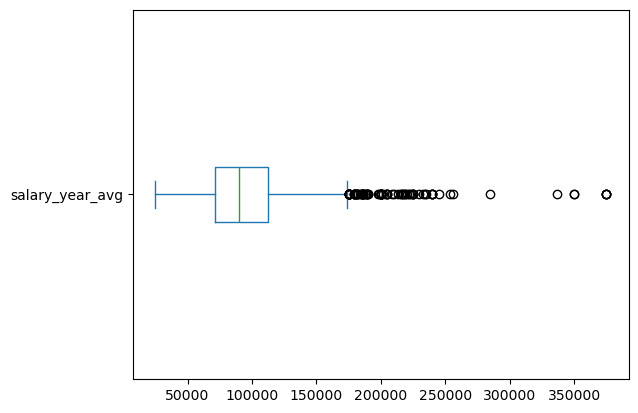

In [5]:
df_DA_US['salary_year_avg'].plot(kind='box',vert=False)

In [11]:
## list of job titles 
job_titles= df['job_title_short'].unique()
job_titles=job_titles.tolist()

## create data set only for us country 
df_us=df[df['job_country']=='United States'].copy()

## remove the NaN value in salary year avg 
df_us= df_us.dropna(subset=['salary_year_avg'])

In [ ]:
## job list 
job_list =[df_us[df_us['job_title_short']== job_titles]['salary_year_avg']for job_titles in job_titles]


92        120000.0
146       129500.0
307       185000.0
339       195000.0
380        97500.0
            ...   
783111    125000.0
784102     90000.0
784191    217500.0
785624    139216.0
785641    150000.0
Name: salary_year_avg, Length: 2915, dtype: float64

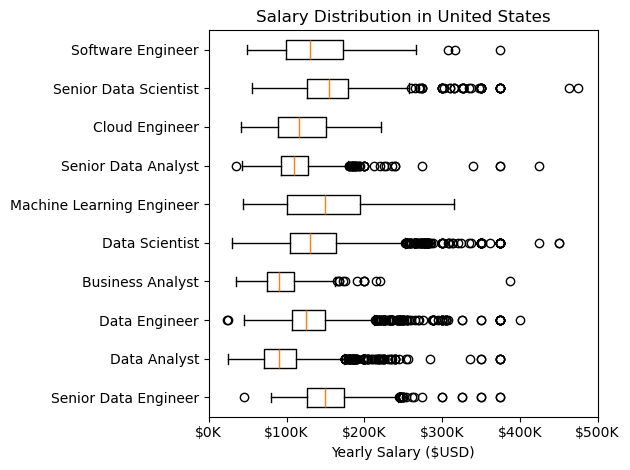

In [23]:
## plot the box plot 
plt.boxplot(job_list, label=job_titles ,vert=False)

## set titles and axis 
plt.title("Salary Distribution in United States")
plt.xlabel('Yearly Salary ($USD)')

## set y axis label 

plt.yticks(range(1, len(job_titles) + 1), job_titles)

## formattting the x axis 
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))
plt.xlim(0,500000)

## layout tight and show box plot 
plt.tight_layout()
plt.show()